# Fibroblast Cell State Exploration: Mucin vs. Fibrosis
This notebook explores the transcriptomic divergence of fibroblast states in Progressive Mucinous Histiocytosis (PMH). We will calculate module scores for mucin production and fibrotic ECM remodeling to determine if these represent sequential stages or distinct stromal populations.

In [6]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)
library(forcats)

In [7]:
out_dir <- "/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/plots/exploration"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

fib_obj <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/processed/fibroblast_detailed_annotated.rds")

DefaultAssay(fib_obj) <- "RNA"

In [8]:
fib_obj@meta.data
colnames(fib_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,pANN_0.25_0.005_226,DF.classifications_0.25_0.005_226,⋯,ProgScore_15,ProgScore_16,ProgScore_17,ProgScore_18,ProgScore_19,ProgScore_20,ProgScore_21,ProgScore_22,Detailed_Label,Macro_Lineage
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
HTY2901_AAACTGGGTGATTACC-1,2901,910,725,0.32967033,800,628,2,4,0.04761905,Singlet,⋯,-0.05861924,-0.04862623,-0.07999291,-0.07666302,-0.04989394,0.099163366,-0.15221511,0.170314899,F2_F3_Perivascular_Disease,F2/F3_Perivascular
HTY2901_AACGGTTAGGGATTTA-1,2901,3254,1896,0.03073141,758,502,4,2,0.04761905,Singlet,⋯,-0.07562887,-0.10500165,0.36874443,0.28949059,-0.09672468,0.360076923,-0.23575131,-0.233562824,F2_Reticular_Disease,F2_Reticular
HTY2901_AACTCGCTCGATTCTG-1,2901,790,577,0.75949367,742,529,4,2,0.23809524,Singlet,⋯,-0.02699173,-0.04875994,0.38032740,0.34988940,-0.04236902,0.221821849,-0.11160696,-0.143061874,F2_Reticular_Disease,F2_Reticular
HTY2901_AACTGGCCACGCCACT-1,2901,755,622,0.00000000,663,548,2,4,0.19047619,Singlet,⋯,-0.05093408,-0.08295884,-0.08888815,-0.07787457,-0.07213714,-0.008643974,-0.12027943,-0.123943234,F2_F3_Perivascular_Disease,F2/F3_Perivascular
HTY2901_AAGCCTCTCAGGTTAA-1,2901,2122,1271,1.17813384,1399,1089,4,2,0.14285714,Singlet,⋯,-0.06682778,-0.07675162,-0.10513510,-0.12063832,-0.06061456,0.484494702,-0.18482898,0.046209745,F2_Reticular_Disease,F2_Reticular
HTY2901_AAGCCTTGTAGCTTGT-1,2901,2745,1403,0.14571949,1374,981,2,4,0.09523810,Singlet,⋯,-0.05635585,-0.07361146,-0.08553737,-0.10363372,-0.07189985,0.160143888,-0.18595687,-0.189676725,F2_F3_Perivascular_Disease,F2/F3_Perivascular
HTY2901_AAGGCACGTCAACTAC-1,2901,919,695,0.97932535,837,632,4,2,0.14285714,Singlet,⋯,-0.04111337,-0.04556419,-0.07241475,-0.07541297,-0.05333400,0.390650660,-0.11123185,-0.133177638,F2_Reticular_Disease,F2_Reticular
HTY2901_ACAACATCATTTCGAC-1,2901,3377,1523,0.14806041,800,338,4,2,0.09523810,Singlet,⋯,0.22437428,0.13380753,-0.06955314,-0.07703822,0.04600951,0.335874220,-0.16439525,0.004812587,F2_Reticular_Disease,F2_Reticular
HTY2901_ACAGGCATCCCGCTGA-1,2901,6439,2638,0.17083398,1199,752,4,2,0.04761905,Singlet,⋯,-0.07637525,-0.10407665,0.04775626,0.02836338,-0.10320563,0.344517057,-0.22485325,-0.076759903,F2_Reticular_Disease,F2_Reticular


[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_SCT"                        "nFeature_SCT"                     
 [7] "SCT_snn_res.0.8"                   "seurat_clusters"                  
 [9] "pANN_0.25_0.005_226"               "DF.classifications_0.25_0.005_226"
[11] "orig.ident1"                       "orig.ident2"                      
[13] "pANN_0.25_0.01_100"                "DF.classifications_0.25_0.01_100" 
[15] "pANN_0.25_0.005_591"               "DF.classifications_0.25_0.005_591"
[17] "pANN_0.25_0.005_182"               "DF.classifications_0.25_0.005_182"
[19] "pANN_0.25_0.23_208"                "DF.classifications_0.25_0.23_208" 
[21] "pANN_0.25_0.005_522"               "DF.classifications_0.25_0.005_522"
[23] "pANN_0.25_0.01_467"                "DF.classifications_0.25_0.01_467" 
[25] "S.Score"                           "G2M.Score"                        
[27] "Phase"                             "batch"                            
[29] "SCT_snn_res.0.05"                  "SCT_snn_res.0.1"                  
[31] "SCT_snn_res.0.2"                   "SCT_snn_res.0.3"                  
[33] "SCT_snn_res.0.4"                   "SCT_snn_res.0.6"                  
[35] "global_cluster"                    "SCT_snn_res.1"                    
[37] "SCT_snn_res.1.2"                   "Detailed_Condition"               
[39] "Condition"                         "ProgScore_1"                      
[41] "ProgScore_2"                       "ProgScore_3"                      
[43] "ProgScore_4"                       "ProgScore_5"                      
[45] "ProgScore_6"                       "ProgScore_7"                      
[47] "ProgScore_8"                       "ProgScore_9"                      
[49] "ProgScore_10"                      "ProgScore_11"                     
[51] "ProgScore_12"                      "ProgScore_13"                     
[53] "ProgScore_14"                      "ProgScore_15"                     
[55] "ProgScore_16"                      "ProgScore_17"                     
[57] "ProgScore_18"                      "ProgScore_19"                     
[59] "ProgScore_20"                      "ProgScore_21"                     
[61] "ProgScore_22"                      "Detailed_Label"                   
[63] "Macro_Lineage"

In [9]:
ncol(fib_obj)

[1] 8352

In [10]:
fib_obj@meta.data %>%
  count(Detailed_Label, name = "Cell_Count") %>%
  arrange(desc(Cell_Count))

Detailed_Label,Cell_Count
<fct>,<int>
F7_Myofibroblast,3016
F1_Superficial_Healthy,1021
F2_F3_Perivascular_Disease,939
F2_Reticular_Disease,656
F4_HF_DP_Disease,584
F3_FRC_like_Healthy,512
Uncertain,503
F4_HF_DPEP_Disease,422
F2_Reticular_Healthy,374


In [11]:
# Generates a dataframe showing the hierarchy and cell counts
fib_obj@meta.data %>%
  count(Macro_Lineage, Detailed_Label, name = "Cell_Count") %>%
  arrange(Macro_Lineage, desc(Cell_Count))

Macro_Lineage,Detailed_Label,Cell_Count
<chr>,<fct>,<int>
F1_Superficial,F1_Superficial_Healthy,1021
F2/F3_Perivascular,F2_F3_Perivascular_Disease,939
F2_Reticular,F2_Reticular_Disease,656
F2_Reticular,F2_Reticular_Healthy,374
F3_FRC_like,F3_FRC_like_Healthy,512
F4_HairFollicle,F4_HF_DP_Disease,584
F4_HairFollicle,F4_HF_DPEP_Disease,422
F4_HairFollicle,F4_HF_DPEP_Healthy,325
F7_Myofibroblast,F7_Myofibroblast,3016


In [12]:
# Simple count table
table(fib_obj$global_cluster, fib_obj$Macro_Lineage)

    
     F1_Superficial F2_Reticular F2/F3_Perivascular F3_FRC_like F4_HairFollicle
  0               0            0                  0           0               0
  1             743          972                363         289             330
  2               0            0                  0           0               0
  3             222           54                547          58             653
  4               0            0                  0           0               0
  5               0            0                  0           0               0
  6               0            0                  0           0               0
  7               0            0                  0           0               0
  8              56            4                 29         165             348
  9               0            0                  0           0               0
  10              0            0                  0           0               0
  11              0            0   

In [13]:
df <- as.data.frame(table(fib_obj$global_cluster, fib_obj$Detailed_Label))
colnames(df) <- c("Cluster", "Lineage", "Count")

df_filtered <- df %>%
mutate(Cluster = factor(Cluster, levels = sort(as.numeric(as.character(unique(Cluster)))))) %>%
group_by(Cluster) %>%
filter(sum(Count) > 0) %>%
ungroup()

print(df)

    Cluster                    Lineage Count
1         0     F1_Superficial_Healthy     0
2         1     F1_Superficial_Healthy   743
3         2     F1_Superficial_Healthy     0
4         3     F1_Superficial_Healthy   222
5         4     F1_Superficial_Healthy     0
6         5     F1_Superficial_Healthy     0
7         6     F1_Superficial_Healthy     0
8         7     F1_Superficial_Healthy     0
9         8     F1_Superficial_Healthy    56
10        9     F1_Superficial_Healthy     0
11       10     F1_Superficial_Healthy     0
12       11     F1_Superficial_Healthy     0
13       12     F1_Superficial_Healthy     0
14       13     F1_Superficial_Healthy     0
15       14     F1_Superficial_Healthy     0
16       15     F1_Superficial_Healthy     0
17       16     F1_Superficial_Healthy     0
18        0       F2_Reticular_Healthy     0
19        1       F2_Reticular_Healthy   374
20        2       F2_Reticular_Healthy     0
21        3       F2_Reticular_Healthy     0
22        

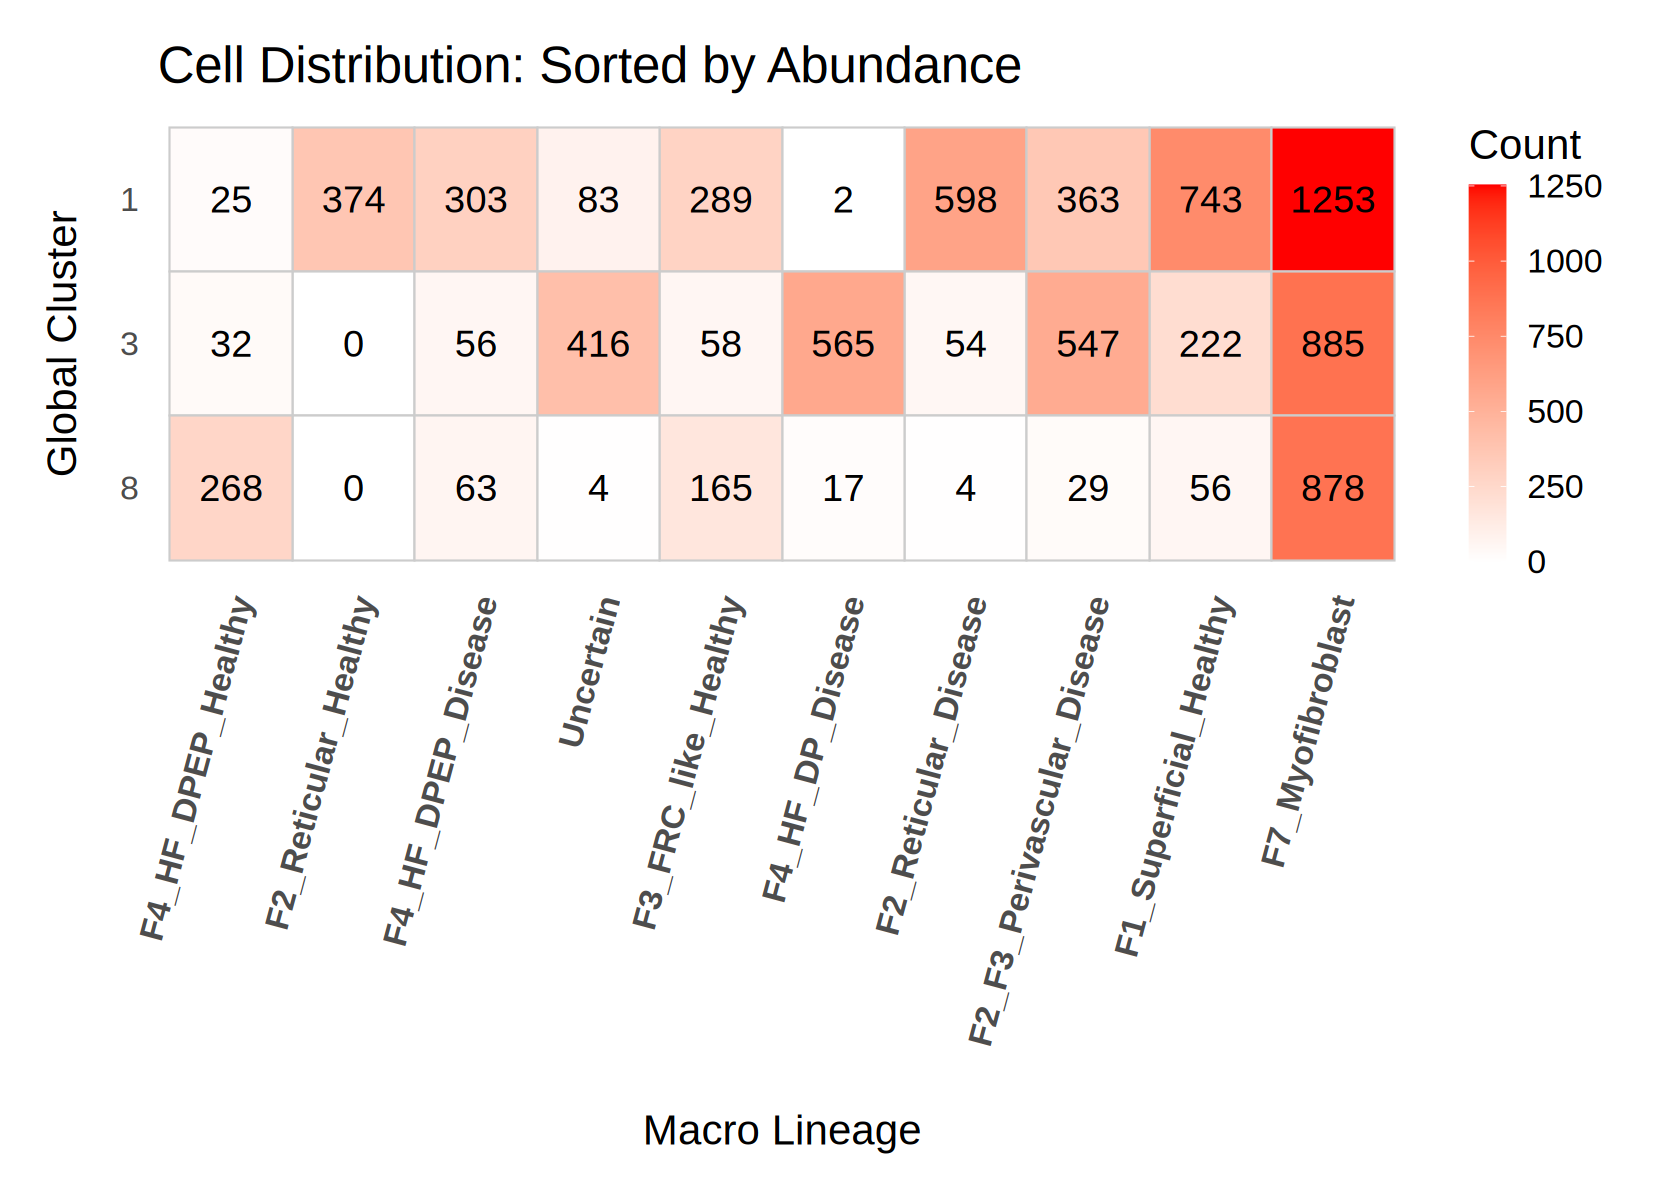

In [14]:
options(repr.plot.width = 14, repr.plot.height = 10)
df_filtered <- df_filtered %>%
  mutate(
    # fct_reorder sorts the Cluster based on the sum of Count. 
    # Use .desc = TRUE if you want the largest clusters at the top.
    Cluster = fct_reorder(Cluster, Count, .fun = sum, .desc = FALSE),
    
    # Optional: Also sort the X-axis (Lineage) from most abundant to least
    Lineage = fct_reorder(Lineage, Count, .fun = sum, .desc = FALSE)
  )

# Now run your exact same ggplot code:
ggplot(df_filtered, aes(x = Lineage, y = Cluster, fill = Count)) +
  geom_tile(color = "gray80") +
  scale_fill_gradient(low = "white", high = "red") +
  geom_text(aes(label = Count), color = "black", size = 8) + 
  theme_minimal(base_size = 25) +
  labs(title = "Cell Distribution: Sorted by Abundance", 
       x = "Macro Lineage", 
       y = "Global Cluster") +
  guides(
    fill = guide_colorbar(
      barheight = unit(8, "cm"),
      barwidth = unit(0.8, "cm")
    )
  ) +
  theme(axis.text.x = element_text(angle = 75, hjust = 1, face = "bold"),
        axis.title.y = element_text(
          margin = margin(r = 20)
        ),
        plot.margin = margin(1, 1, 1, 1, unit = "cm"),
        panel.grid = element_blank())

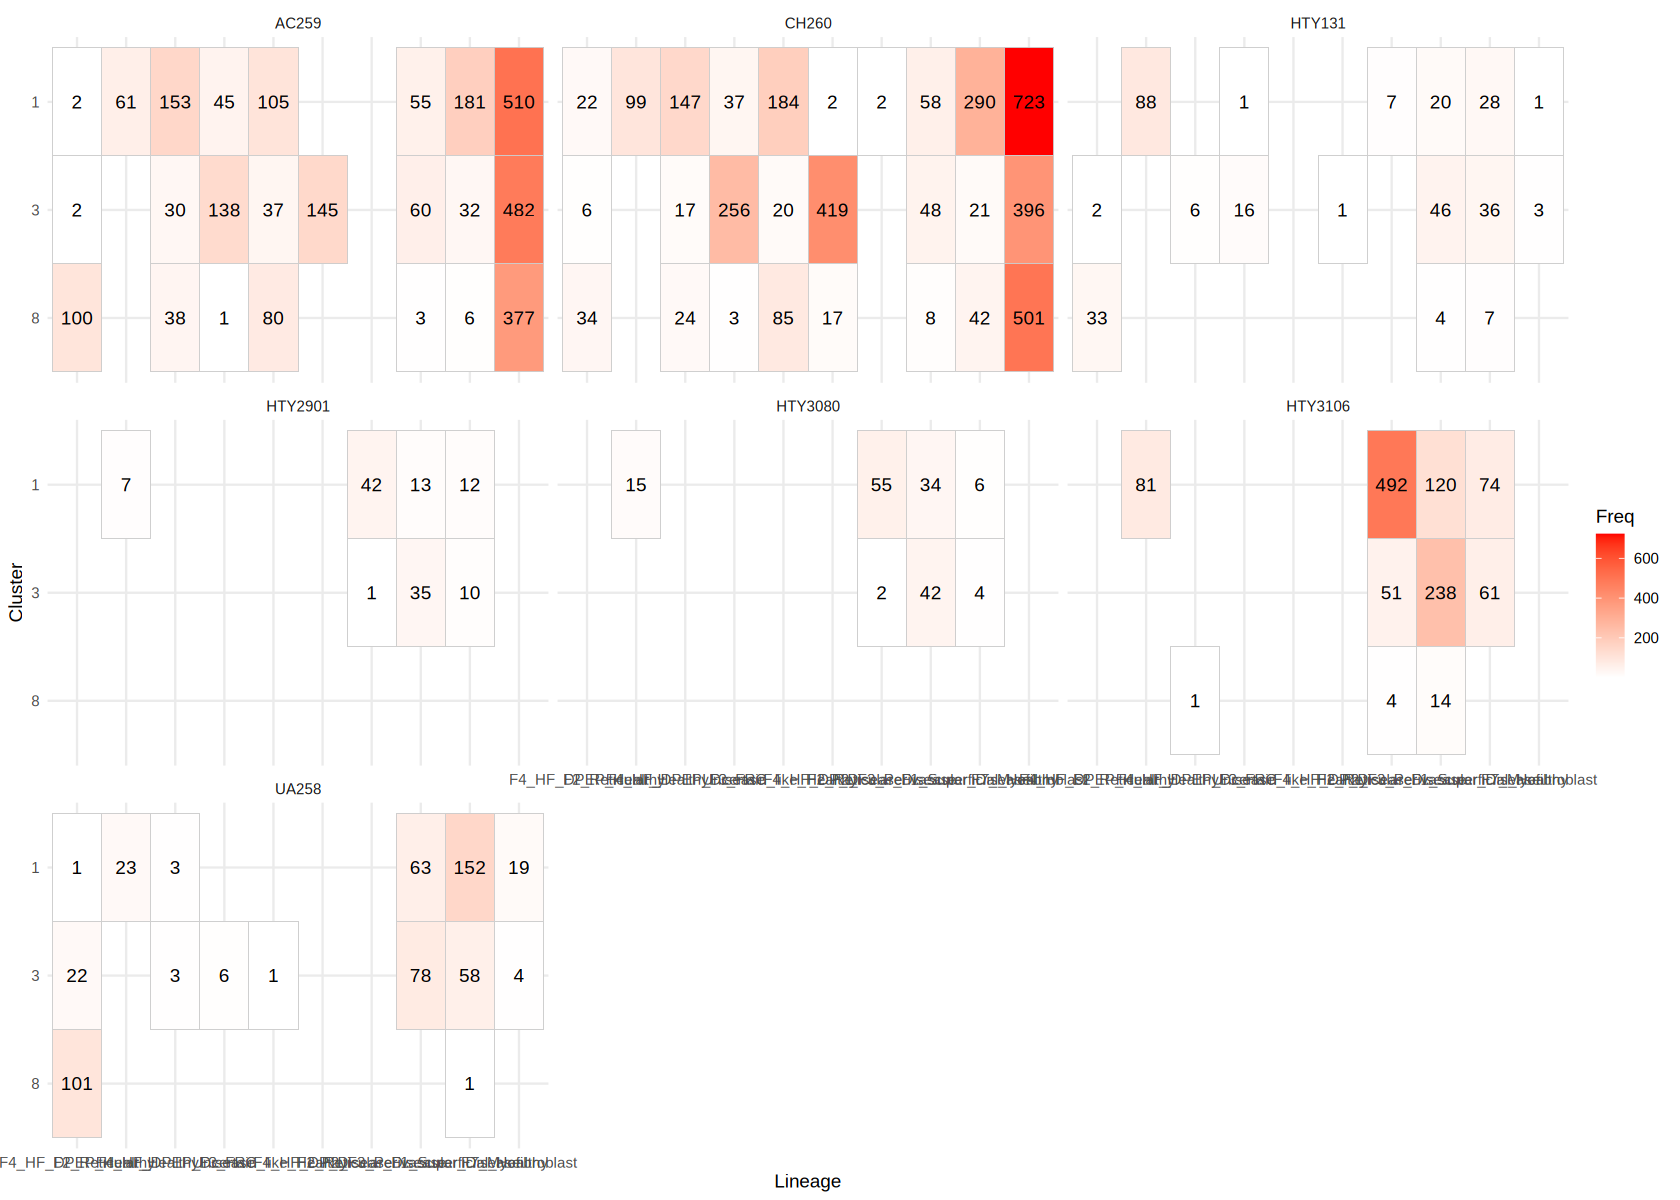

In [23]:
df <- as.data.frame(table(
  Cluster = fib_obj$global_cluster,
  Lineage = fib_obj$Detailed_Label,
  Sample = fib_obj$orig.ident2
))

df <- df %>%
  filter(Freq > 0) %>%
  mutate(
    Cluster = fct_reorder(Cluster, Freq, .fun = sum),
    Lineage = fct_reorder(Lineage, Freq, .fun = sum)
  )

ggplot(df, aes(Lineage, Cluster, fill = Freq)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = Freq), size = 4) +
  scale_fill_gradient(low = "white", high = "red") +
  facet_wrap(~Sample) +
  theme_minimal()

In [42]:
df <- as.data.frame(table(
  Cluster = fib_obj$global_cluster,
  Lineage = fib_obj$Detailed_Label,
  Group = fib_obj$Detailed_Condition   # replace with your metadata column
))

df <- df %>%
  filter(Freq > 0)

p <- ggplot(df, aes(Lineage, Cluster, fill = Freq)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = Freq), size = 4) +
  scale_fill_gradient(low = "white", high = "red") +
  facet_wrap(~Group, nrow = 1) +
  theme_bw(base_size = 16) +
  theme(
    axis.text.x = element_text(angle = 60, hjust = 1),
    panel.grid = element_blank()
  )

  ggsave("pmh_healthy_absolute.png", p, width = 28, height = 7, dpi = 300)

In [16]:
macrophage <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/macrophage/processed/macrophage_detailed_annotated.rds")
colnames(macrophage@meta.data)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_SCT"                        "nFeature_SCT"                     
 [7] "SCT_snn_res.0.8"                   "seurat_clusters"                  
 [9] "pANN_0.25_0.005_226"               "DF.classifications_0.25_0.005_226"
[11] "orig.ident1"                       "orig.ident2"                      
[13] "pANN_0.25_0.01_100"                "DF.classifications_0.25_0.01_100" 
[15] "pANN_0.25_0.005_591"               "DF.classifications_0.25_0.005_591"
[17] "pANN_0.25_0.005_182"               "DF.classifications_0.25_0.005_182"
[19] "pANN_0.25_0.23_208"                "DF.classifications_0.25_0.23_208" 
[21] "pANN_0.25_0.005_522"               "DF.classifications_0.25_0.005_522"
[23] "pANN_0.25_0.01_467"                "DF.classifications_0.25_0.01_467" 
[25] "S.Score"                           "G2M.Score"                        
[27] "Phase"                             "batch"                            
[29] "SCT_snn_res.0.05"                  "SCT_snn_res.0.1"                  
[31] "SCT_snn_res.0.2"                   "SCT_snn_res.0.3"                  
[33] "SCT_snn_res.0.4"                   "SCT_snn_res.0.6"                  
[35] "global_cluster"                    "SCT_snn_res.1"                    
[37] "SCT_snn_res.1.2"                   "Detailed_Condition"               
[39] "Condition"                         "ProgScore_1"                      
[41] "ProgScore_2"                       "ProgScore_3"                      
[43] "Detailed_Label"

In [17]:
table(macrophage$Detailed_Label)


M0_Non_Polarized  M1_Inflammatory M2_Wound_Healing 
            1353              250              146 

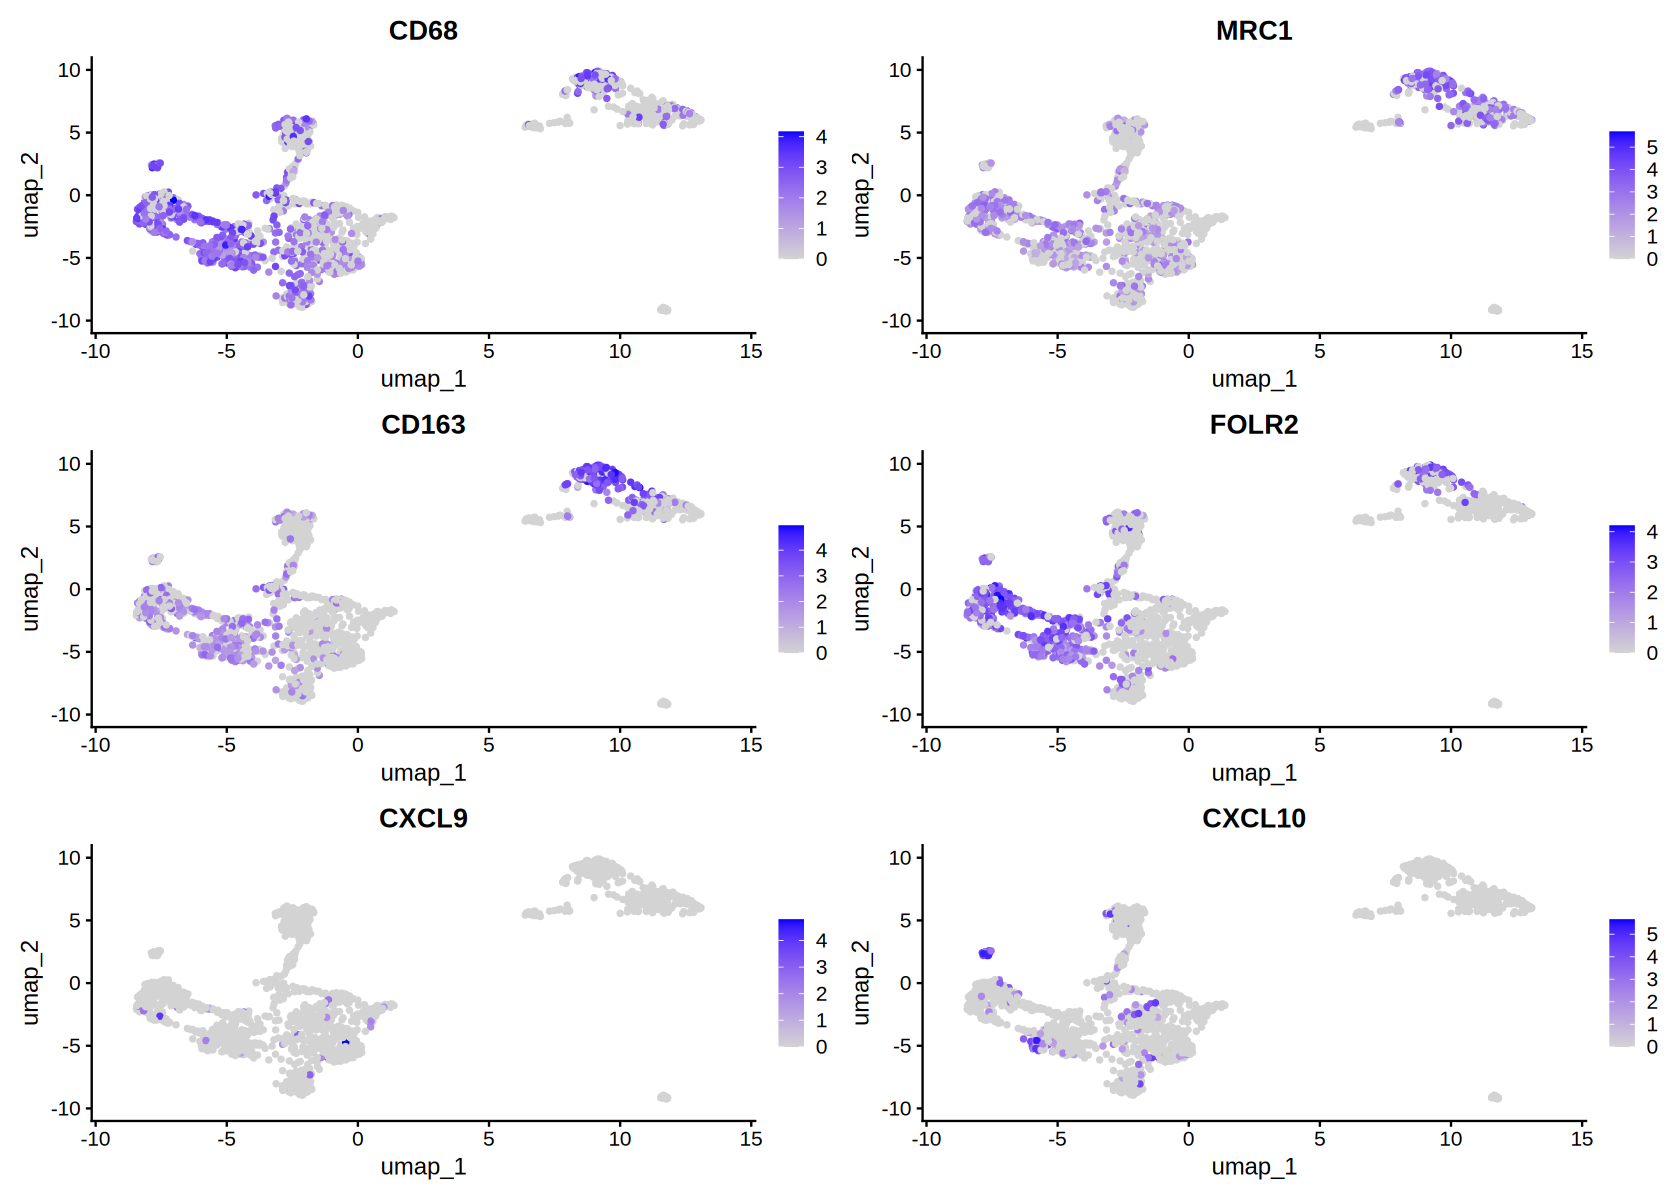

In [18]:
FeaturePlot(macrophage, features = c(
    "CD68",
    "MRC1",
    "CD163",
    "FOLR2",
    "CXCL9",
    "CXCL10"
))

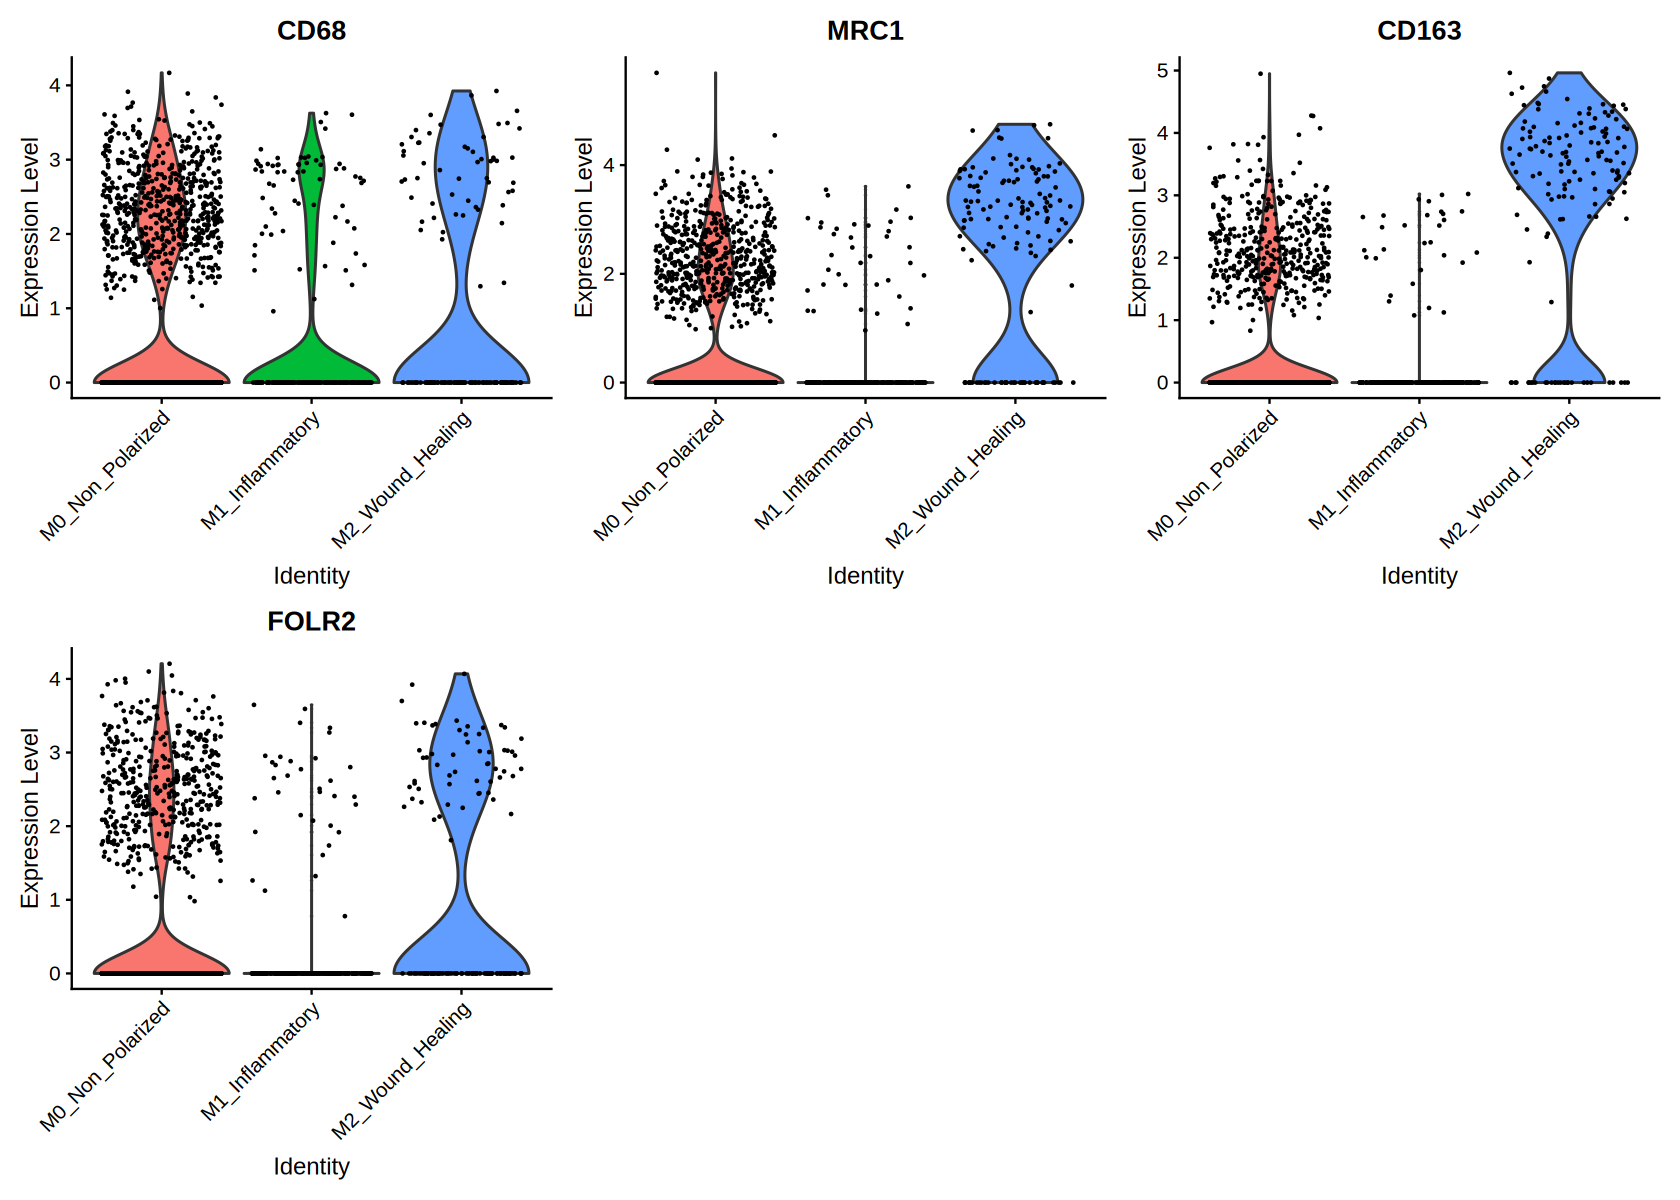

In [19]:
VlnPlot(macrophage,
         features = c("CD68","MRC1","CD163","FOLR2"))

In [20]:
sum(macrophage$Detailed_Label == "M0_Non_Polarized")

[1] 1353

In [43]:
monocle <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/pseudotime_global/monocle3_cds.rds")

In [47]:
colnames(colData(monocle))

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_SCT"                        "nFeature_SCT"                     
 [7] "SCT_snn_res.0.8"                   "seurat_clusters"                  
 [9] "pANN_0.25_0.005_226"               "DF.classifications_0.25_0.005_226"
[11] "orig.ident1"                       "orig.ident2"                      
[13] "pANN_0.25_0.01_100"                "DF.classifications_0.25_0.01_100" 
[15] "pANN_0.25_0.005_591"               "DF.classifications_0.25_0.005_591"
[17] "pANN_0.25_0.005_182"               "DF.classifications_0.25_0.005_182"
[19] "pANN_0.25_0.23_208"                "DF.classifications_0.25_0.23_208" 
[21] "pANN_0.25_0.005_522"               "DF.classifications_0.25_0.005_522"
[23] "pANN_0.25_0.01_467"                "DF.classifications_0.25_0.01_467" 
[25] "S.Score"                           "G2M.Score"                        
[27] "Phase"                             "batch"                            
[29] "SCT_snn_res.0.05"                  "SCT_snn_res.0.1"                  
[31] "SCT_snn_res.0.2"                   "SCT_snn_res.0.3"                  
[33] "SCT_snn_res.0.4"                   "SCT_snn_res.0.6"                  
[35] "global_cluster"                    "SCT_snn_res.1"                    
[37] "SCT_snn_res.1.2"                   "Detailed_Condition"               
[39] "Condition"                         "ProgScore_1"                      
[41] "ProgScore_2"                       "ProgScore_3"                      
[43] "ProgScore_4"                       "ProgScore_5"                      
[45] "ProgScore_6"                       "ProgScore_7"                      
[47] "ProgScore_8"                       "ProgScore_9"                      
[49] "ProgScore_10"                      "ProgScore_11"                     
[51] "ProgScore_12"                      "ProgScore_13"                     
[53] "ProgScore_14"                      "ProgScore_15"                     
[55] "ProgScore_16"                      "ProgScore_17"                     
[57] "ProgScore_18"                      "ProgScore_19"                     
[59] "ProgScore_20"                      "ProgScore_21"                     
[61] "ProgScore_22"                      "Detailed_Label"                   
[63] "Macro_Lineage"                     "clusters"                         
[65] "Size_Factor"

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


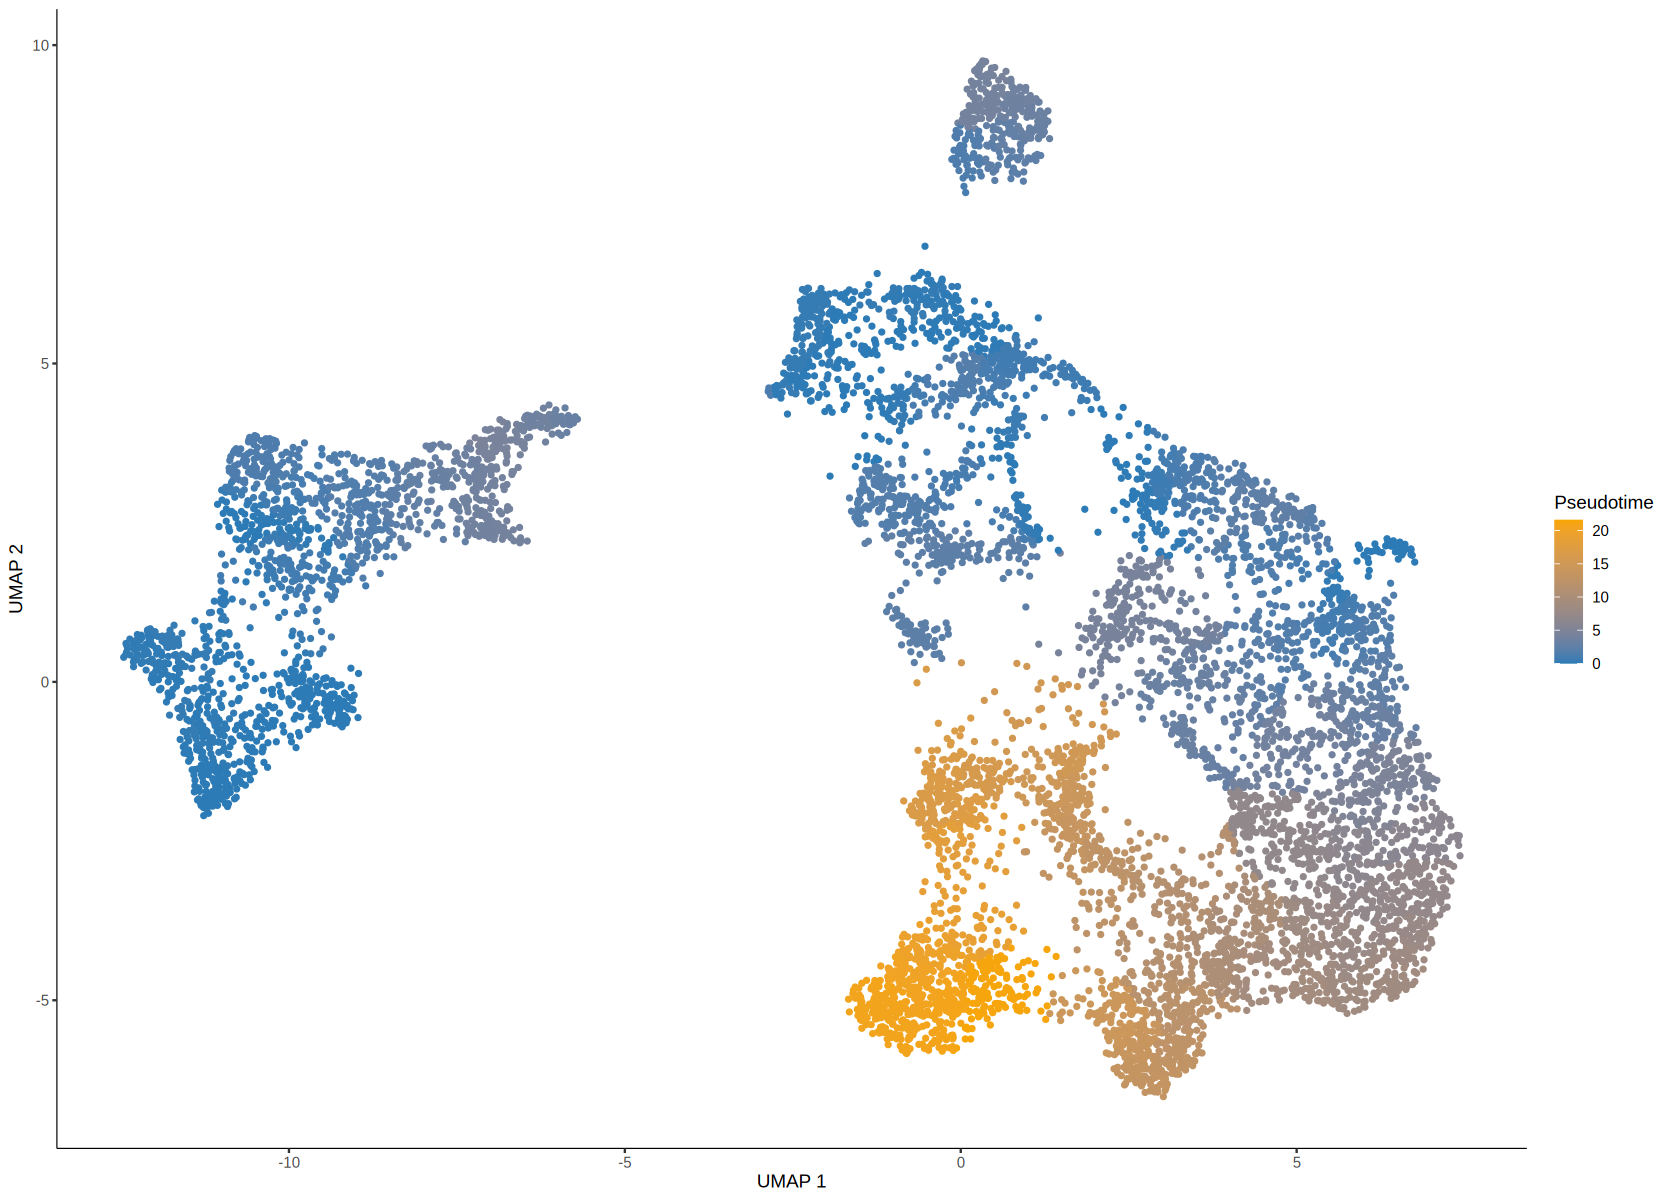

In [72]:
library(ggplot2)

p <- plot_cells(
  monocle,
  reduction_method = "UMAP",
  color_cells_by = "pseudotime",
  show_trajectory_graph = FALSE,
  label_cell_groups = FALSE,
  label_leaves = FALSE,
  label_branch_points = FALSE,
  cell_size = 1.0
)

p$layers[[1]]$aes_params$colour <- NA

p +
scale_color_gradient(
  low = "#2C7BB6",
  high = "#F9A602"
) + guides(color = guide_colorbar(title = "Pseudotime"))

ggsave("pseudotime.png", p, width=8, height=8, dpi=300)

Cells aren't colored in a way that allows them to be grouped.



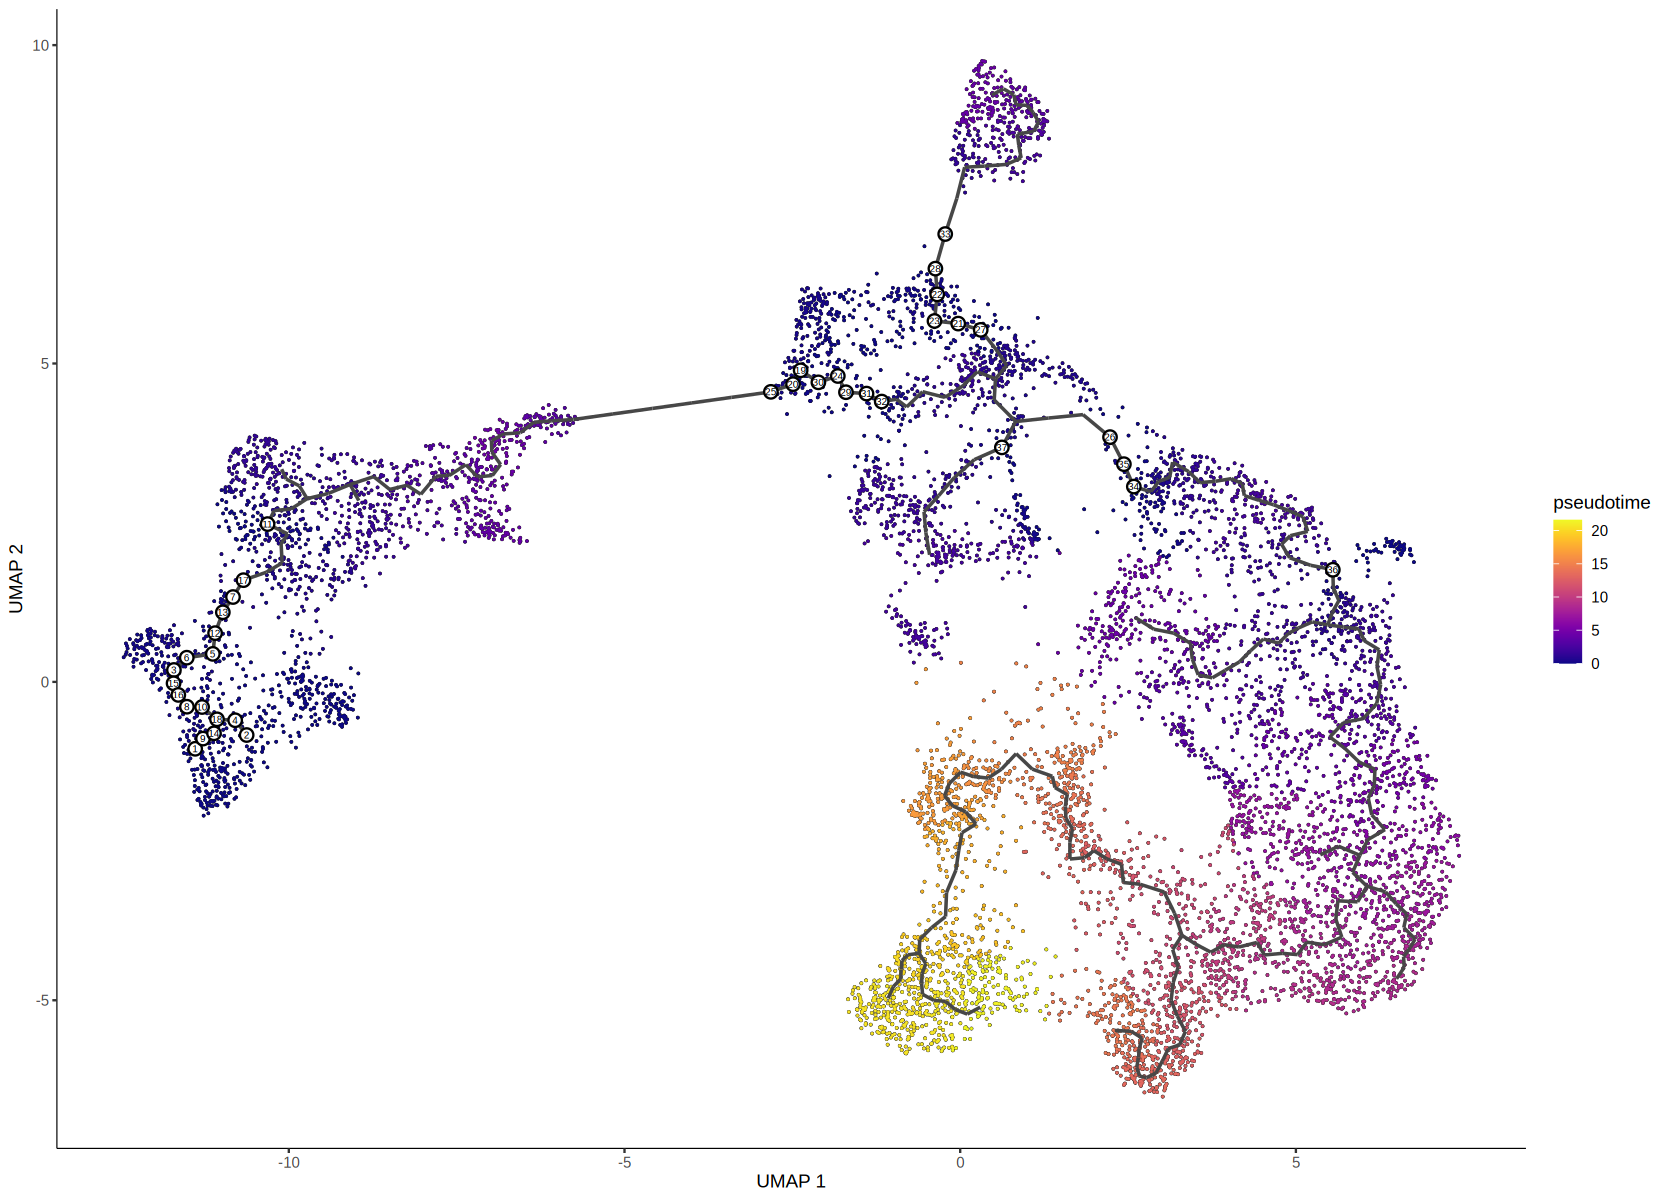

In [50]:
plot_cells(
    monocle,
    color_cells_by = "pseudotime",
    label_groups_by_cluster = FALSE,
    label_leaves = FALSE,
    label_branch_points = FALSE
)